##Transfer Learning using MobileNetV2
Project Title

Aerial Object Classification & Detection

##Introduction

In the previous notebook, we built a Custom CNN model to classify aerial images into Bird and Drone categories.

While CNN models perform well, training them from scratch requires large datasets and computational resources.

To improve performance, we now use Transfer Learning, which allows us to leverage knowledge from models that were already trained on massive datasets such as ImageNet.

In this notebook, we will use MobileNetV2, a lightweight and efficient convolutional neural network architecture widely used for image classification tasks.

#Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

#Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
train_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/train"
val_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/Aerial_Object_Project/classification_dataset/test"

#Data Preprocessing

Image Data Generators

In [8]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

#Load Dataset

In [9]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(

    val_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


##Loading MobileNetV2

MobileNetV2 is a pretrained CNN trained on ImageNet dataset containing millions of images.

We will use its pretrained feature extraction layers and add our own classification layers.

#Load Pretrained MobileNetV2

In [10]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Base Model Layers

In [11]:
for layer in base_model.layers:

    layer.trainable = False

##Building Transfer Learning Model

We now add custom classification layers on top of MobileNetV2.

Add Custom Layers

In [12]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

Compile Model

In [13]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

Train Model

In [15]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 902s 11s/step - accuracy: 0.9395 - loss: 0.1519 - val_accuracy: 0.9706 - val_loss: 0.0955
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9666 - loss: 0.0871 - val_accuracy: 0.9683 - val_loss: 0.0957
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.9730 - loss: 0.0651 - val_accuracy: 0.9661 - val_loss: 0.0800
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.9771 - loss: 0.0633 - val_accuracy: 0.9638 - val_loss: 0.0769
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9786 - loss: 0.0567 - val_accuracy: 0.9661 - val_loss: 0.0876
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9872 - loss: 0.0441 - val_accuracy: 0.9729 - val_loss: 0.0758
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9872 - loss: 0.0387 - val_accuracy: 0.9706 - val_loss: 0.0986
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.9895 - loss: 0.0383 - val_accuracy: 0.9638 - 

##Model Evaluation

Accuracy Graph

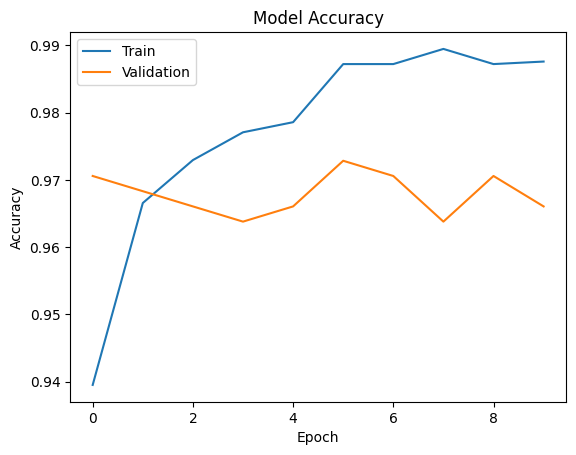

In [16]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

Loss Graph

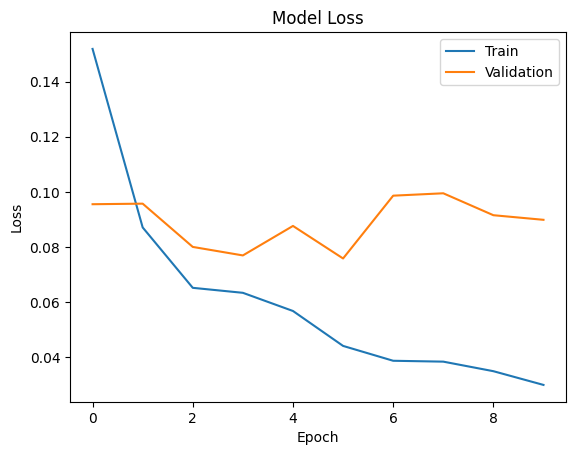

In [17]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

##Test Dataset

In [18]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='binary',

    shuffle=False
)

Found 215 images belonging to 2 classes.


##Predictions

In [19]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 8s/step


##Classification Report

In [20]:
print(classification_report(test_generator.classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       121
           1       0.96      0.97      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



##Confusion Matrix

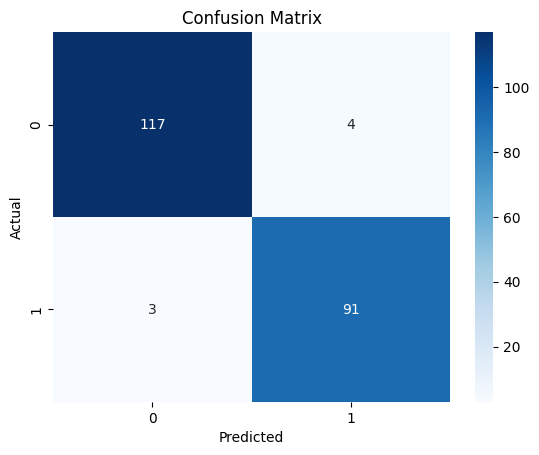

In [21]:
cm = confusion_matrix(test_generator.classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

##Save Model

In [22]:
model.save("/content/drive/MyDrive/Aerial_Object_Project/models/mobilenet_model.h5")

print("Transfer learning model saved successfully")

Transfer learning model saved successfully


##Conclusion

In this notebook we implemented Transfer Learning using MobileNetV2.

Compared to the custom CNN model, transfer learning typically provides:


*   higher accuracy
*   faster convergence
*   better generalization

This model will be compared with the CNN model to determine the best performing classifier.